Исходные столбцы и типы данных:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal            str
target        int64
dtype: object

Первые 5 строк:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

   ca        thal  target  
0   0       fixed       0  
1   3      normal       1  
2   2  reversible       0  
3   0      normal       0  
4   0      normal       0  

П

/tmp/ipykernel_74105/1186694778.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns



Точность модели: 0.8033

Матрица ошибок:
[[43  1]
 [11  6]]

Отчёт о классификации:
              precision    recall  f1-score   support

           0       0.80      0.98      0.88        44
           1       0.86      0.35      0.50        17

    accuracy                           0.80        61
   macro avg       0.83      0.67      0.69        61
weighted avg       0.81      0.80      0.77        61



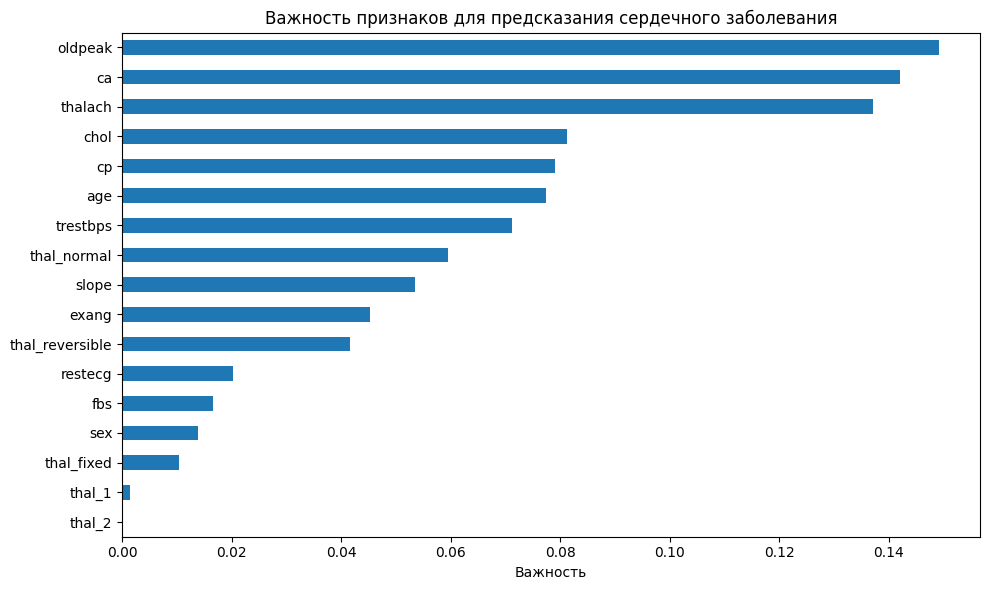

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('heart.csv')
print("Исходные столбцы и типы данных:")
print(df.dtypes)
print("\nПервые 5 строк:")
print(df.head())

# Проверка пропусков
print("\nПропуски:\n", df.isnull().sum())

# Преобразование категориальных признаков в числовые
# Определяем столбцы, которые имеют тип object (текст)
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nКатегориальные столбцы: {list(categorical_cols)}")

if len(categorical_cols) > 0:
    # Применяем one-hot encoding (создаёт новые столбцы 0/1)
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=False)
    print("После кодирования. Новые столбцы:", df.shape[1])
else:
    print("Категориальных столбцов не найдено.")

# Целевая переменная (предполагается, что она называется 'target')
# Убедитесь, что target не попала под one-hot encoding
if 'target' in df.columns:
    y = df['target']
    X = df.drop('target', axis=1)
else:
    # Если target тоже текстовая, её нужно оставить как есть (0/1)
    # Но обычно target уже числовой (0 или 1)
    raise ValueError("Столбец 'target' не найден. Проверьте имена столбцов.")

print(f"\nРазмер X: {X.shape}, y: {y.shape}")
print("Распределение target:\n", y.value_counts())

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Обучающая: {X_train.shape}, Тестовая: {X_test.shape}")

# Обучение модели
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Предсказание и оценка
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nТочность модели: {accuracy:.4f}")
print("\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print("\nОтчёт о классификации:")
print(classification_report(y_test, y_pred))

# График важности признаков
importances = model.feature_importances_
features = X.columns
feat_imp = pd.Series(importances, index=features).sort_values()

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh')
plt.title('Важность признаков для предсказания сердечного заболевания')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()